Name : Pedro Vital Guimarães \
Course : Data Analysis Using the Python Programming Language \
Universidade Nova de Lisboa - FCT

# Case Study 14

## Guiding question
How does the final grade vary depending on preschool attendance, taking age into account?

### Suggested variables
*   nursery
*   age
*   G3


# Task 1 - Data reading, selection, and organization


In [ ]:
#Bibliotecas
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Importar a base de dados
df_Mat = pd.read_csv("student-mat.csv", sep=";")

#Na medida em que a variável "Nursery" é a 20º coluna encontra-se oculta/abreviada por defeito.
#De forma a culmatar esta condição, utilizei a função .set_option() configurando de forma a observar as 33 colunas.
pd.set_option('display.max_columns', None)

#Através da função .head, observa-se as primeiras 5 linhas da base de dados.
print("\nGlimpse da base de dados:")
print(df_Mat.head())

#Através da função .info, observei informação sobre a base de dados e quanto às variáveis, o seu tipo.
#Relativamente às variáveis sugeridas, identifiquei Nursery como categórica, Age e G3 como numéricas.
print("\nInformação sobre a base de dados:")
print(df_Mat.info())

#Criação de uma base de dados com as variáveis seleccionadas.
df_Q14 = df_Mat[["nursery", "age", "G3"]]

#Agregação das variáveis numéricas selecionadas para mais fácil operacionalização dos cálculos posteriores.
Var_AG3 = ["age", "G3"]



Glimpse da base de dados:
  school sex  age address famsize Pstatus  Medu  Fedu     Mjob      Fjob  \
0     GP   F   18       U     GT3       A     4     4  at_home   teacher   
1     GP   F   17       U     GT3       T     1     1  at_home     other   
2     GP   F   15       U     LE3       T     1     1  at_home     other   
3     GP   F   15       U     GT3       T     4     2   health  services   
4     GP   F   16       U     GT3       T     3     3    other     other   

   reason guardian  traveltime  studytime  failures schoolsup famsup paid  \
0  course   mother           2          2         0       yes     no   no   
1  course   father           1          2         0        no    yes   no   
2   other   mother           1          2         3       yes     no  yes   
3    home   mother           1          3         0        no    yes  yes   
4    home   father           1          2         0        no    yes  yes   

  activities nursery higher internet romantic  famrel

# Task 2 — Descriptive statistics

In [ ]:
#Variáveis Numéricas
#Através da função .describe, observação de estatísticas descriptivas.
#Observação de medidas de tendência central (M, mediana de forma indireta através do Q2) e medidas de dispersão (std, Min, Max, Quartis).
print("\nEstatísticas Descriptivas das Variáveis Numéricas:")
print(df_Q14[Var_AG3].describe())
print("\nMédia das Variáveis Numéricas:") #Cálculo específico, caso o .describe não seja suficiente.
print(df_Q14[Var_AG3].mean())

#Observação de outras medidas de dispersão (Variância e Amplitude Interquartil)
print("\nVariância:")
print(df_Q14[Var_AG3].var())

print("\nAmplitude Interquartil:")
print(df_Q14[Var_AG3].quantile(0.75) - df_Q14[Var_AG3].quantile(0.25))

print("\nMínimo:") #Cálculo específico, caso o .describe não seja suficiente.
print(df_Q14[Var_AG3].min())

print("\nMáximo:") #Cálculo específico, caso o .describe não seja suficiente.
print(df_Q14[Var_AG3].max())

#Variável Categórica
#Através da função .value_counts, observação da Frequência Absoluta.
print("\nFrequências Absolutas dos níveis de Nursery:")
print(df_Q14["nursery"].value_counts())

#Ao acrescentarmos o argumento normalize=TRUE, observamos a Frequência Relativa.
print("\nFrequências Relativas dos níveis de Nursery:")
print(df_Q14['nursery'].value_counts(normalize=True))

#Através da função .mode, obtemos a moda.
print("\nModa de Nursery:")
print(df_Q14["nursery"].mode())

#Comparação bivariada simples
#Observamos no output a M e DP das notas finais (G3) pela frequência ou não no pré-escolar(Nursery).
print("\nClassificações finais (G3) pelos níveis de Nursery:")
print(df_Q14.groupby("nursery")["G3"].agg(['mean', 'std']))



Estatísticas Descriptivas das Variáveis Numéricas:
              age          G3
count  395.000000  395.000000
mean    16.696203   10.415190
std      1.276043    4.581443
min     15.000000    0.000000
25%     16.000000    8.000000
50%     17.000000   11.000000
75%     18.000000   14.000000
max     22.000000   20.000000

Média das Variáveis Numéricas:
age    16.696203
G3     10.415190
dtype: float64

Variância:
age     1.628285
G3     20.989616
dtype: float64

Amplitude Interquartil:
age    2.0
G3     6.0
dtype: float64

Mínimo:
age    15
G3      0
dtype: int64

Máximo:
age    22
G3     20
dtype: int64

Frequências Absolutas dos níveis de Nursery:
nursery
yes    314
no      81
Name: count, dtype: int64

Frequências Relativas dos níveis de Nursery:
nursery
yes    0.794937
no     0.205063
Name: proportion, dtype: float64

Moda de Nursery:
0    yes
Name: nursery, dtype: object

Classificações finais (G3) pelos níveis de Nursery:
              mean       std
nursery                     
no

# Task 3 — Graphic visualization



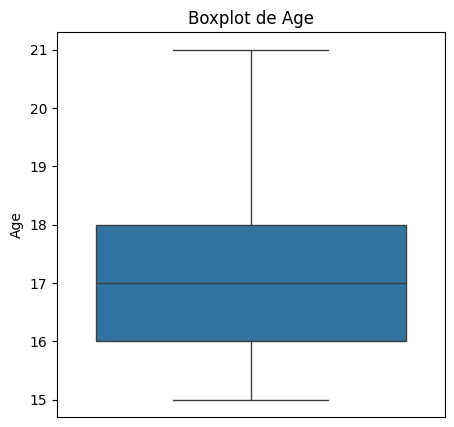

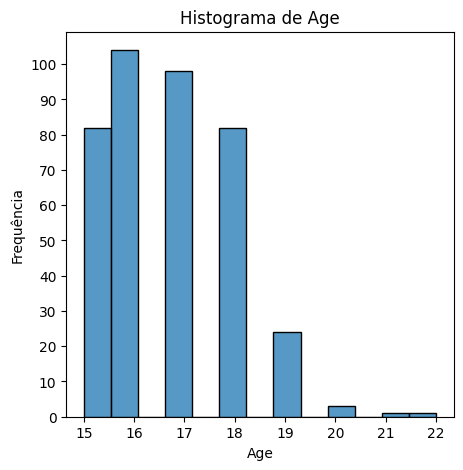

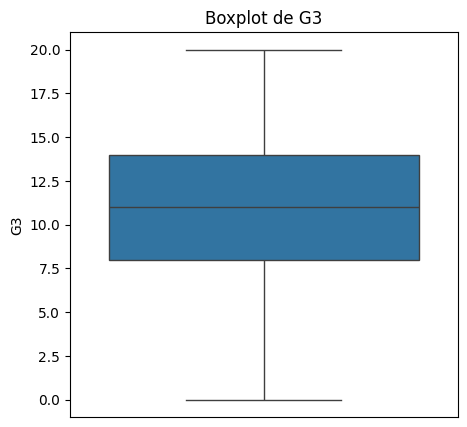

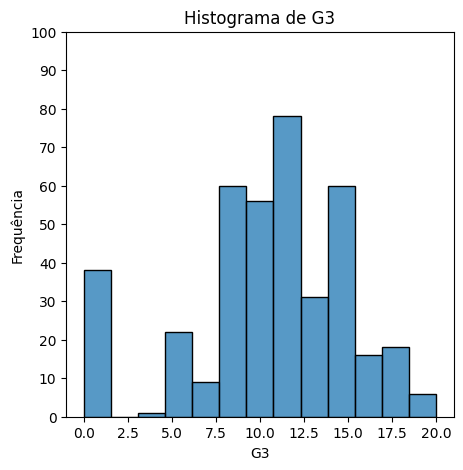

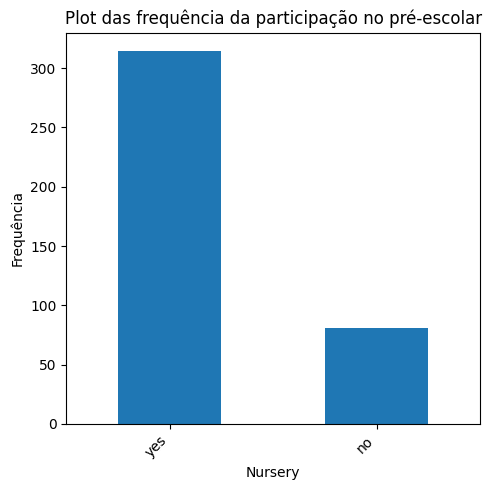

In [ ]:
#Visualização Unidimensional

#Variáveis Numéricas

#Variável Age
#Boxplot para Age
plt.figure(figsize=(5, 5))
sns.boxplot(y=df_Q14["age"].dropna(), showfliers=False)
plt.title("Boxplot de Age")
plt.ylabel("Age")
plt.xticks([])
plt.show()

#Histograma para Age
plt.figure(figsize=(5, 5))
sns.histplot(df_Q14["age"].dropna(), kde=False)
plt.title("Histograma de Age")
plt.xlabel("Age")
plt.ylabel("Frequência")
plt.yticks(range(0, 110, 10))
plt.show()

#Variável G3
#Boxplot para G3
plt.figure(figsize=(5, 5))
sns.boxplot(y=df_Q14["G3"].dropna(), showfliers=False)
plt.title("Boxplot de G3")
plt.ylabel("G3")
plt.xticks([])
plt.show()
#Histograma para G3
plt.figure(figsize=(5, 5))
sns.histplot(df_Q14["G3"].dropna(), kde=False)
plt.title("Histograma de G3")
plt.xlabel("G3")
plt.ylabel("Frequência")
plt.yticks(range(0, 110, 10))
plt.show()


#Variável Categórica
#Plot / gráfico de barras para Nursery
df_Q14["nursery"].value_counts(normalize  = False).plot(kind="bar", figsize=(5, 5))
plt.title("Plot das frequência da participação no pré-escolar")
plt.xlabel("Nursery")
plt.ylabel("Frequência")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

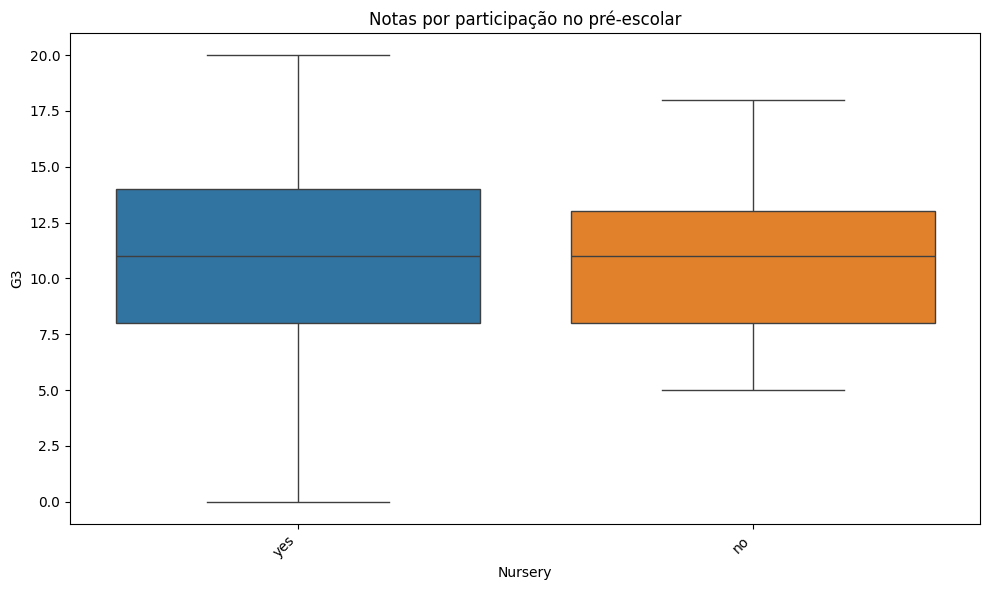

In [ ]:
#Visualização bidimensional
#Boxplots da Comparação variada simples
#Classificações finais (G3) pela participação no pré-escolar (nursery).
plt.figure(figsize=(10, 6))
sns.boxplot(x="nursery", y="G3", hue = "nursery", data=df_Q14, showfliers=False)
plt.title("Notas por participação no pré-escolar")
plt.xlabel("Nursery")
plt.ylabel("G3")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

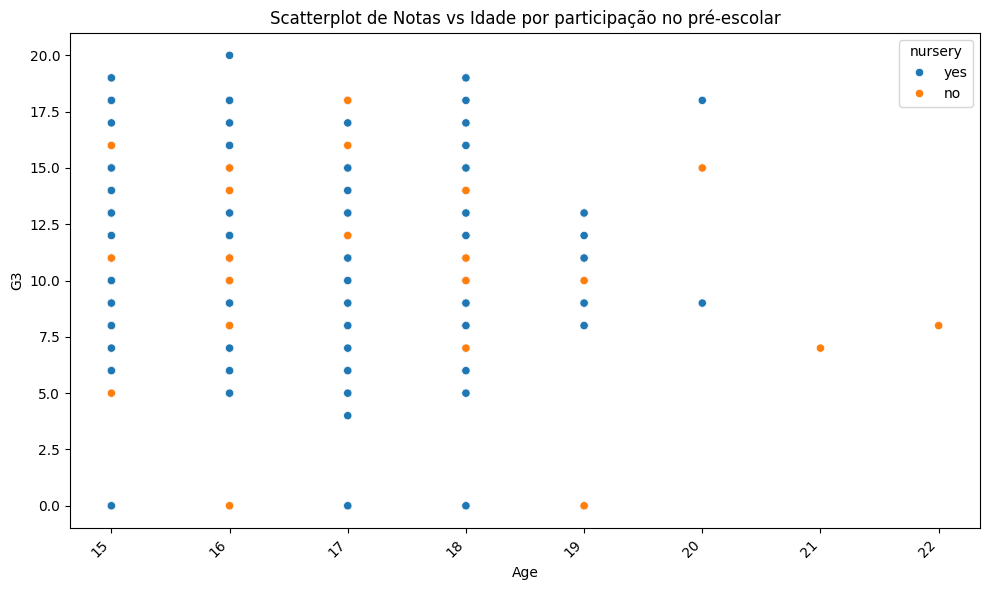

In [ ]:
#Visualização Tridimensional
#Scatterplot da Notas vs Age por Nursery
plt.figure(figsize=(10, 6))
sns.scatterplot(x="age", y="G3", hue="nursery", data=df_Q14)
plt.title("Scatterplot de Notas vs Idade por participação no pré-escolar")
plt.xlabel("Age")
plt.ylabel("G3")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

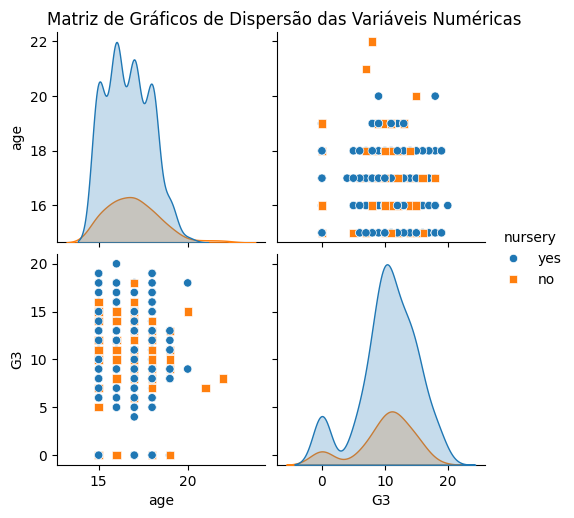

In [ ]:
#Matriz de Gráficos de Dispersão das Variáveis Numéricas
sns.pairplot(data=df_Q14, vars=Var_AG3, hue='nursery', diag_kind='kde', markers=['o','s'])
plt.suptitle('Matriz de Gráficos de Dispersão das Variáveis Numéricas', y=1.02)
plt.show()

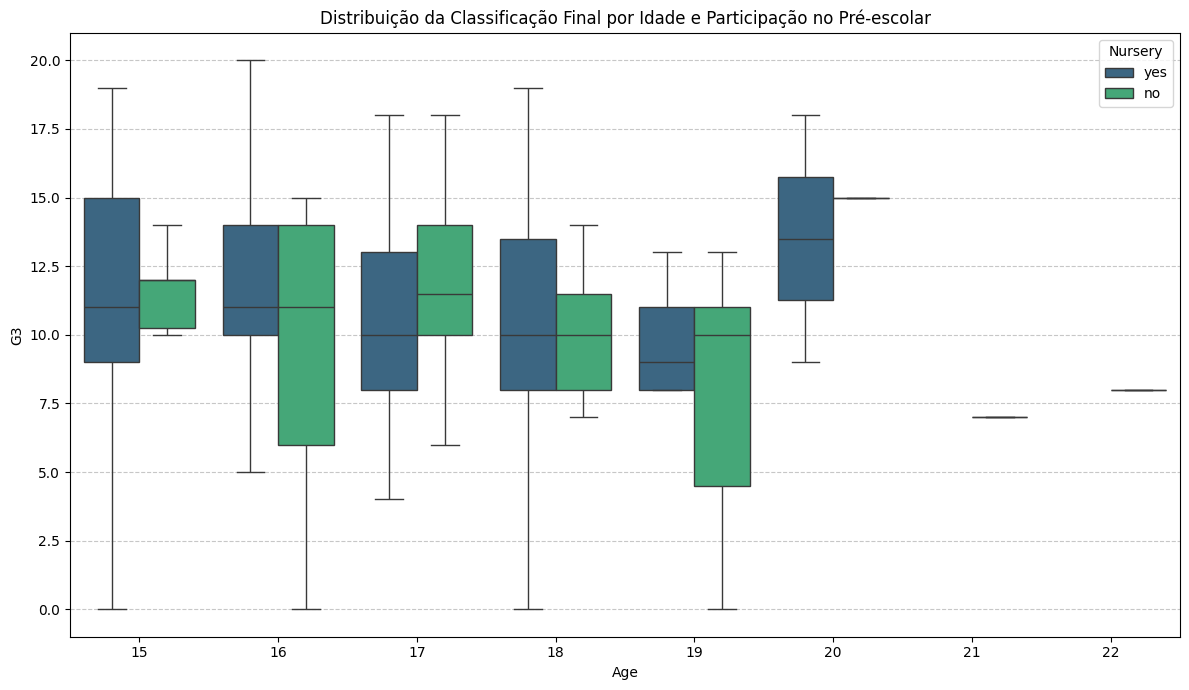

In [ ]:
#Grouped Boxplot
#Distribuição da Classificação Final (G3) por Idade e Frequência do Pré-escolar (Nursery)
plt.figure(figsize=(12, 7))
sns.boxplot(x='age', y='G3', hue='nursery', data=df_Q14, palette='viridis', showfliers=False)
plt.title('Distribuição da Classificação Final por Idade e Participação no Pré-escolar')
plt.xlabel('Age')
plt.ylabel('G3')
plt.legend(title='Nursery')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Task 4 - Interpretation and Conclusion


The average age of the sample is 16.7 ± 1.28.

The average final grades of the sample is 10.42 ± 4.58.

Most students attended preschool (314 Yes, 79.5%; 81 No, 20.5%).

The average final grade of students who attended preschool is higher (10.5 ± 4.56; 9.95 ± 4.59).

# How is the final grade distributed according to preschool attendance, considering the students' age?

The previous data, together with the observation of the Grouped Boxplot, show a consistent tendency for students who attended preschool to have higher final grades in most age groups.

Observing the Grouped Boxplot, we also verified that the median of the final grades of students who attended preschool is higher than or comparable to those who did not attend, never being lower.

In older ages (+20), the number of students is reduced (< 5), which compromises the analysis and representativeness of the conclusions.

In summary, from this exploratory analysis, we can state that across different ages, the final grade is generally higher in students who attended preschool.